# Homework 2

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

np.random.seed(42)

N = 200
LR = 0.1
EPOCHS = 100

def mse_loss(theta, X, y):
    return np.mean((X @ theta - y) ** 2)

def mse_grad(theta, X, y):
    return 2 / len(y) * X.T @ (X @ theta - y)

def run_sgd(theta, X, y, lr, epochs, batch_size):
    n = len(y)
    losses = []
    traj = [theta.copy()]
    grad_norms = []

    for _ in range(epochs):
        idx = np.random.permutation(n) if batch_size < n else np.arange(n)
        for start in range(0, n, batch_size):
            batch = idx[start:start + batch_size]
            theta = theta - lr * mse_grad(theta, X[batch], y[batch])

        traj.append(theta.copy())
        losses.append(mse_loss(theta, X, y))
        grad_norms.append(np.linalg.norm(mse_grad(theta, X, y)))

    return theta, np.array(losses), np.array(traj), np.array(grad_norms)

# Exercise 1

In [2]:
x = np.arange(1, N + 1) / N
y1 = 2 * x + 1 + np.random.normal(0, 0.1, N)
# reshape so X1@theta can be used by mse_loss to compute f
X1 = np.column_stack([np.ones(N), x])

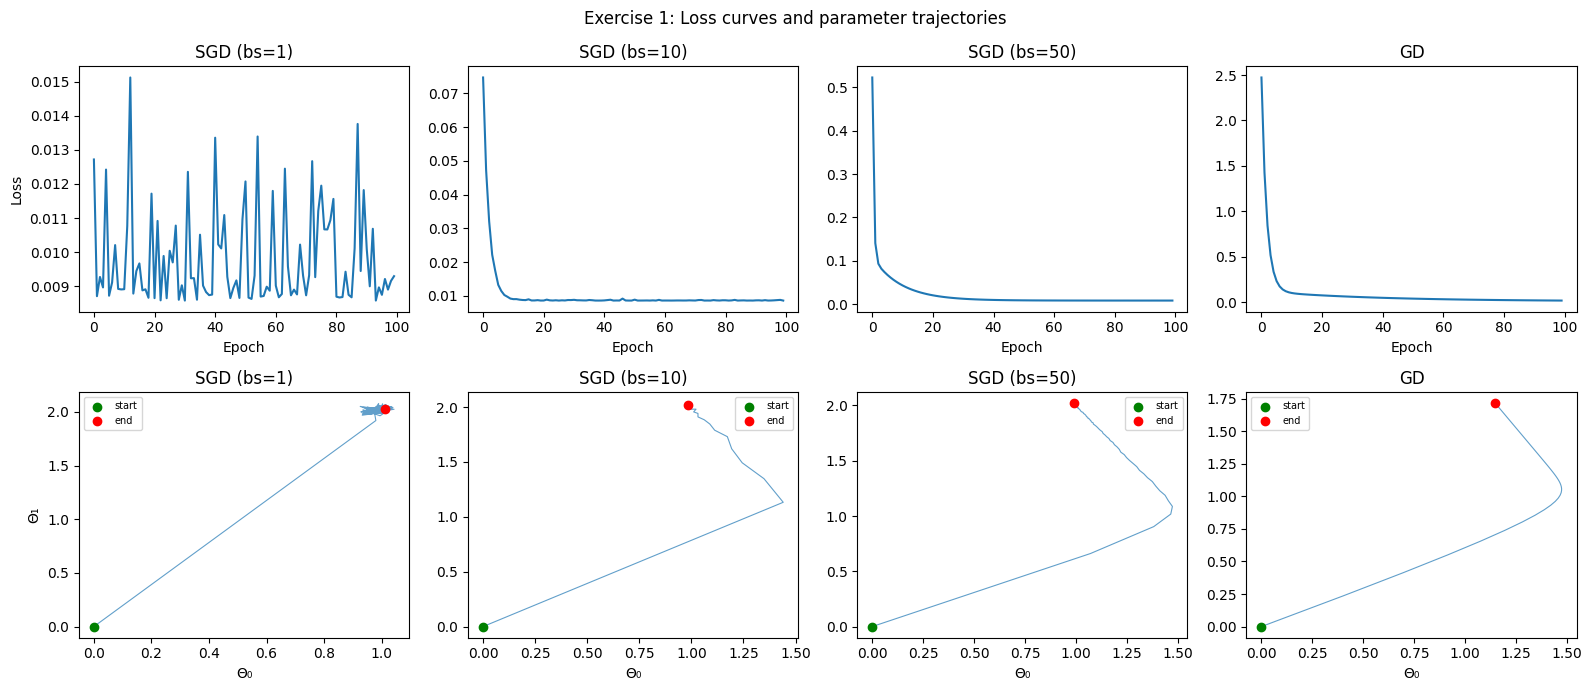

In [3]:
BATCH_SIZES = [1, 10, 50, N]

fig, axes = plt.subplots(2, 4, figsize=(16, 7))
for col, bs in enumerate(BATCH_SIZES):
    _, losses, traj, _ = run_sgd(np.zeros(2), X1, y1, LR, EPOCHS, bs)
    name = "GD" if bs == N else f"SGD (bs={bs})"
    axes[0, col].plot(losses)
    axes[0, col].set(title=name, xlabel="Epoch", ylabel="Loss" if col == 0 else "")
    axes[1, col].plot(traj[:, 0], traj[:, 1], alpha=0.7, lw=0.8)
    axes[1, col].scatter(*traj[0], c='g', zorder=5, label='start')
    axes[1, col].scatter(*traj[-1], c='r', zorder=5, label='end')
    axes[1, col].set(title=name, xlabel="Θ₀", ylabel="Θ₁" if col == 0 else "")
    axes[1, col].legend(fontsize=7)

plt.suptitle("Exercise 1: Loss curves and parameter trajectories")
plt.tight_layout()
plt.show()

# Exercise 2

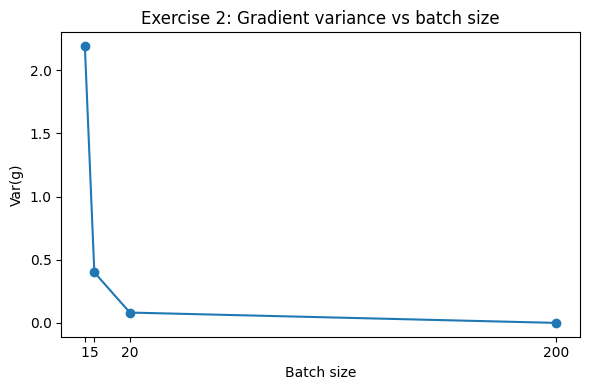

In [4]:
BATCH_SIZES_EX2 = [1, 5, 20, N]
K = 100
theta_fixed = np.array([0.5, 0.5])

variances = []
for bs in BATCH_SIZES_EX2:
    grads = []
    for _ in range(K):
        idx = np.random.choice(N, bs, replace=False)
        grads.append(mse_grad(theta_fixed, X1[idx], y1[idx]))
    grads = np.array(grads)
    g_bar = grads.mean(axis=0)
    variances.append(np.mean(np.linalg.norm(grads - g_bar, axis=1) ** 2))

plt.figure(figsize=(6, 4))
plt.plot(BATCH_SIZES_EX2, variances, "o-")
plt.xlabel("Batch size"); plt.ylabel("Var(g)")
plt.title("Exercise 2: Gradient variance vs batch size")
plt.xticks(BATCH_SIZES_EX2)
plt.tight_layout()
plt.show()

# Exercise 3

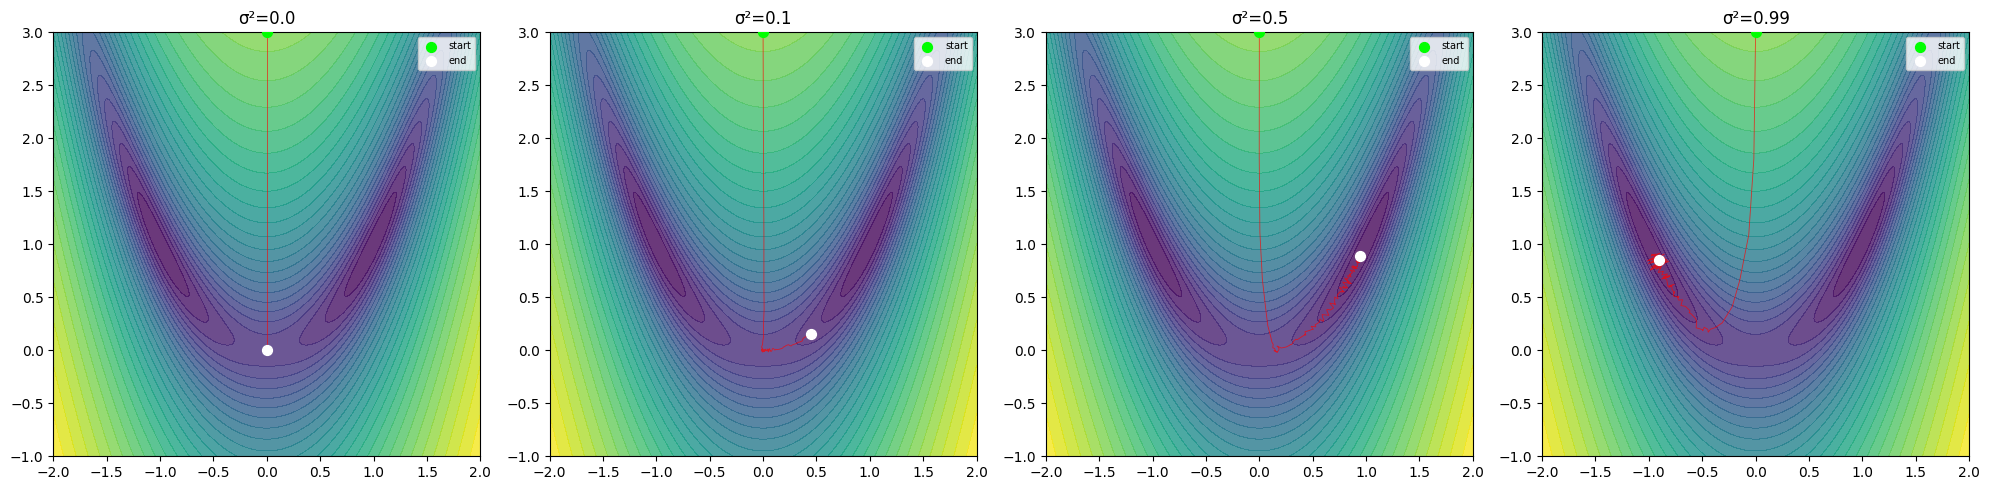

In [5]:
def ex3_loss(theta):
    th1, th2 = theta
    return (th1**2 - 1)**2 + 10*(th2 - th1**2)**2

def ex3_grad(theta):
    th1, th2 = theta
    return np.array([4*th1*(th1**2 - 1) - 40*th1*(th2 - th1**2), 20*(th2 - th1**2)])

def run_sgd_noisy(theta, lr, n_steps, sigma):
    traj = [theta.copy()]
    for _ in range(n_steps):
        new_theta = theta - lr * (ex3_grad(theta) + np.random.normal(0, sigma, 2))
        if not np.all(np.isfinite(new_theta)):
            break
        theta = new_theta
        traj.append(theta.copy())
    return np.array(traj)

g1 = np.linspace(-2, 2, 300)
g2 = np.linspace(-1, 3, 300)
G1, G2 = np.meshgrid(g1, g2)
Z = (G1**2 - 1)**2 + 10*(G2 - G1**2)**2


fig, axes = plt.subplots(1, 4, figsize=(20, 5))
for ax, sigma2 in zip(axes, [0.0, 0.1, 0.5, 0.99]):
    traj = run_sgd_noisy(np.array([0.0, 3.0]), 0.02, 100, np.sqrt(sigma2))

    ax.contourf(G1, G2, np.log1p(Z), levels=30, cmap="viridis", alpha=0.8)
    ax.plot(traj[:, 0], traj[:, 1], "r-", lw=0.6, alpha=0.7)
    ax.scatter(*traj[0],  c="lime",  zorder=5, s=50, label="start")
    ax.scatter(*traj[-1], c="white", zorder=5, s=50, label="end")
    ax.set_title(f"σ²={sigma2}")
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()

# Exercise 4

In [6]:
df = pd.read_csv("assets/insurance.csv")
X4_raw = df[["age", "bmi", "children"]].values.astype(float)
y4_raw = df["charges"].values.astype(float)

X4_std = (X4_raw - X4_raw.mean(0)) / X4_raw.std(0)
y4_std = (y4_raw - y4_raw.mean()) / y4_raw.std()

X4 = np.column_stack([np.ones(len(X4_std)), X4_std])
y4 = y4_std
N4 = len(y4)
print(f"Dataset: {N4} samples, {X4.shape[1]} params (bias + 3 features)")

Dataset: 1338 samples, 4 params (bias + 3 features)


  SGD (bs=1): [-0.0454  0.2272  0.0947  0.0553]
  SGD (bs=10): [-0.0377  0.2935  0.1605  0.0794]
  SGD (bs=50): [0.0012 0.2808 0.1681 0.0542]
  GD: [-0.      0.246   0.1529  0.0503]


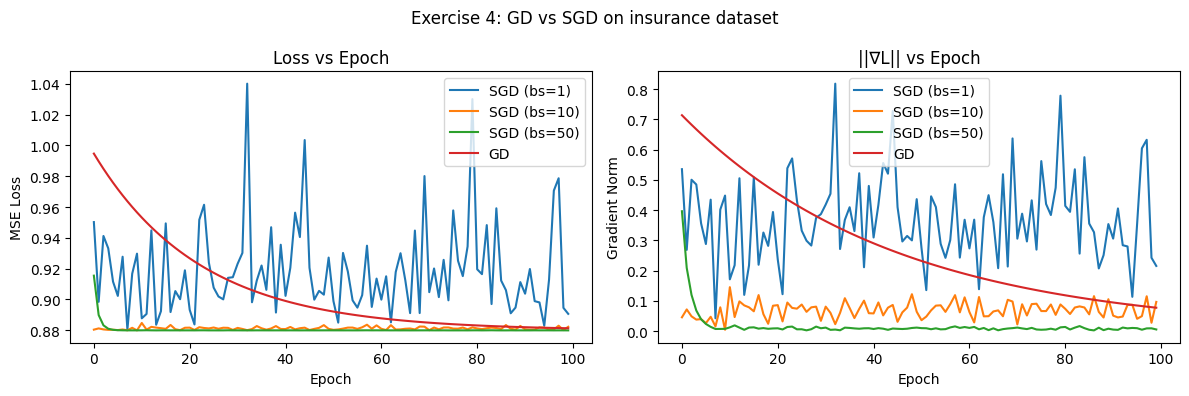

In [7]:
BATCH_SIZES_EX4 = [1, 10, 50, N4]
LR4, EPOCHS4 = 1e-2, 100

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))
for bs in BATCH_SIZES_EX4:
    theta_f, losses, _, grad_norms = run_sgd(np.zeros(4), X4, y4, LR4, EPOCHS4, bs)
    label = "GD" if bs == N4 else f"SGD (bs={bs})"
    ax1.plot(losses, label=label)
    ax2.plot(grad_norms, label=label)
    print(f"  {label}: {np.round(theta_f, 4)}")

ax1.set(title="Loss vs Epoch", xlabel="Epoch", ylabel="MSE Loss")
ax2.set(title="||∇L|| vs Epoch", xlabel="Epoch", ylabel="Gradient Norm")
ax1.legend(); ax2.legend()
plt.suptitle("Exercise 4: GD vs SGD on insurance dataset")
plt.tight_layout()
plt.show()
